# QSVM — Quantum Support Vector Machine per la classificazione di jet adronici

In questo notebook viene implementato e confrontato un classificatore quantistico basato su Quantum Support Vector Machine (QSVM) con i corrispondenti classificatori classici (SVM con kernel lineare, polinomiale e RBF) per il problema della discriminazione di jet adronici in fisica delle alte energie.
Il problema di classificazione consiste nel distinguere jet prodotti dal decadimento del quark top dai jet di fondo QCD (Quantum ChromoDynamics) generati da collisioni protone-protone. I dati provengono dall'esperimento ATLAS al Large Hadron Collider (LHC) del CERN.
## Dataset
Il dataset è composto da 10.000 jet, ciascuno descritto da 400 feature cinematiche relative ai costituenti del jet.
## Struttura
Il notebook è composto così:

-Riduzione dimensionale tramite un autoencoder con Sinkhorn loss, che comprime le 400 feature originali alle 16 rappresentazioni latenti più significative.
-Classificazione classica con SVM (kernel lineare, polinomiale di grado 3, RBF)
-Classificazione quantistica con QSVM, in cui il kernel è calcolato tramite due diversi circuiti quantistici con feature map
-Confronto delle prestazioni tramite le metriche standard: accuracy, F1 score e AUC della curva ROC

In [2]:
#AUTOENCODER
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import geomloss
import matplotlib
matplotlib.use("Agg")  # <-- salva su file senza aprire finestre
import matplotlib.pyplot as plt
import os
import pennylane as qml
import pennylane.numpy as pnp
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# PARTE 1 — CARICA DATI


infile = "train_nominal_000.h5"
f = h5py.File(infile, 'r')
Njet = 10000
NConstituents = 100

clus_E   = f['fjet_clus_E'][:Njet,   :NConstituents]
clus_eta = f['fjet_clus_eta'][:Njet,  :NConstituents]
clus_phi = f['fjet_clus_phi'][:Njet,  :NConstituents]
clus_pt  = f['fjet_clus_pt'][:Njet,   :NConstituents]
labels   = f["labels"][:Njet]

X = np.concatenate([
    clus_pt.reshape(Njet, -1),
    clus_eta.reshape(Njet, -1),
    clus_phi.reshape(Njet, -1),
    clus_E.reshape(Njet, -1)
], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.float32)
dataset  = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(dataset, batch_size=256, shuffle=True)
valid_loader = DataLoader(dataset, batch_size=512, shuffle=False)
print("DataLoader pronto! Numero batch:", len(train_loader))



# PARTE 2 — AUTOENCODER SINKCLASS


class AE_sinkclass(nn.Module):
    def __init__(self, device="cpu", hpars=None):
        super().__init__()
        self.device = device
        self.hp = {
            "ae_type":          "sinkclass",
            "ae_layers":        [400, 256, 128, 64, 32, 16,8],
            "lr":               0.0005,
            "adam_betas":       (0.9, 0.999),
            "labels_dimension": 2,
            "class_weight":     0.7,
            "sinkh_weight":     0.3,
            "class_layers":     [64, 32, 16, 1],
        }
        if hpars:
            self.hp.update({k: hpars[k] for k in hpars.keys() & self.hp.keys()})

        latent_dim = self.hp["ae_layers"][-1]
        labels_dim = self.hp["labels_dimension"]

        self.encoder    = self._build_mlp(self.hp["ae_layers"], final_activation=False)
        self.decoder    = self._build_mlp(list(reversed(self.hp["ae_layers"])), final_activation=True)
        self.classifier = self._build_classifier([latent_dim] + self.hp["class_layers"])

        first_hidden = self.hp["ae_layers"][1]
        self.noise_enc_data = nn.Sequential(
            nn.Linear(self.hp["ae_layers"][0], first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden),            nn.LeakyReLU(0.2),
        )
        self.noise_enc_labl = nn.Sequential(
            nn.Linear(labels_dim, first_hidden), nn.LeakyReLU(0.2),
        )
        self.noise_gen = nn.Sequential(
            nn.Linear(2 * first_hidden, first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden // 2),  nn.LeakyReLU(0.2),
            nn.Linear(first_hidden // 2, latent_dim),
        )

        self.recon_loss_fn = nn.MSELoss(reduction="mean")
        self.class_loss_fn = nn.BCELoss(reduction="mean")
        self.laten_loss_fn = geomloss.SamplesLoss("sinkhorn", blur=0.05, scaling=0.95, diameter=0.01, debias=True)

        self.best_valid_loss   = float("inf")
        self.epochs_no_improve = 0
        self.early_stop_limit  = 30
        self.all_train_loss, self.all_valid_loss = [], []
        self.all_recon_loss, self.all_laten_loss, self.all_class_loss = [], [], []
        self.to(self.device)

    @staticmethod
    def _build_mlp(layers, final_activation=True):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.ReLU(True))
            elif final_activation:
                mods.append(nn.Tanh())
        return nn.Sequential(*mods)

    @staticmethod
    def _build_classifier(layers):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            mods.append(nn.Sigmoid() if i == len(layers) - 2 else nn.LeakyReLU(0.2))
        return nn.Sequential(*mods)

    def _onehot(self, y_batch):
        B = y_batch.shape[0]
        y_map = torch.zeros(B, self.hp["labels_dimension"], device=y_batch.device)
        return y_map.scatter_(1, y_batch.long().reshape(-1, 1), 1.0)

    def _generate_noise(self, x_noise, y_onehot):
        return self.noise_gen(torch.cat([self.noise_enc_data(x_noise),
                                         self.noise_enc_labl(y_onehot)], dim=1))

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.classifier(latent), self.decoder(latent)

    def compute_loss(self, x_data, y_data):
        y_onehot     = self._onehot(y_data)
        latent, classif, recon = self.forward(x_data)
        latent_noise = self._generate_noise(torch.rand_like(x_data), y_onehot)
        recon_loss   = self.recon_loss_fn(recon, x_data)
        class_loss   = self.class_loss_fn(classif.flatten(), y_data.float())
        laten_loss   = self.laten_loss_fn(latent, latent_noise)
        return (recon_loss + self.hp["sinkh_weight"] * laten_loss
                + self.hp["class_weight"] * class_loss,
                recon_loss, laten_loss, class_loss)

    def train_autoencoder(self, train_loader, valid_loader, epochs=200, outdir=None):
        optimizer = optim.Adam(self.parameters(), lr=self.hp["lr"], betas=self.hp["adam_betas"])
        #print(f"\nTraining AE | latent={self.hp['ae_layers'][-1]}, early_stop={self.early_stop_limit}\n")
        for epoch in range(epochs):
            self.train()
            batch_sum, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                total, *_ = self.compute_loss(xb, yb)
                optimizer.zero_grad(); total.backward(); optimizer.step()
                batch_sum += total.item(); n += 1
            train_loss = batch_sum / n
            vt, vr, vl, vc = self._validate(valid_loader, outdir)
            self.all_train_loss.append(train_loss); self.all_valid_loss.append(vt)
            self.all_recon_loss.append(vr);         self.all_laten_loss.append(vl)
            self.all_class_loss.append(vc)
            warn = "  [!] cls~random" if vc > 0.68 else ""
             #print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.5f}  valid={vt:.5f}  "
                 # f"recon={vr:.5f}  sink={vl:.5f}  cls={vc:.5f}{warn}")
            if self.epochs_no_improve >= self.early_stop_limit:
                print(f"Early stopping at epoch {epoch+1}."); break

    @torch.no_grad()
    def _validate(self, valid_loader, outdir):
        self.eval()
        xv, yv = next(iter(valid_loader))
        xv, yv = xv.to(self.device), yv.to(self.device)
        total, r, l, c = self.compute_loss(xv, yv)
        if total.item() < self.best_valid_loss:
            self.best_valid_loss = total.item(); self.epochs_no_improve = 0
            #print(f"  ✓ new best: {self.best_valid_loss:.5f}")
            if outdir:
                os.makedirs(outdir, exist_ok=True)
                torch.save(self.state_dict(), f"{outdir}/best_model.pt")
        else:
            self.epochs_no_improve += 1
        return total.item(), r.item(), l.item(), c.item()

    def loss_plot(self, outdir=None):
        epochs = list(range(1, len(self.all_train_loss) + 1))
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("Sinkclass AE — loss per epoca", fontsize=14)
        for ax, s1, s2, title, l1, l2 in [
            (axes[0,0], self.all_train_loss, self.all_valid_loss, "Total loss",           "train", "valid"),
            (axes[0,1], self.all_recon_loss,  None,               "Reconstruction (MSE)", "recon", None),
            (axes[1,0], self.all_laten_loss,  None,               "Sinkhorn (latent)",    "sink",  None),
            (axes[1,1], self.all_class_loss,  None,               "Classification (BCE)", "cls",   None),
        ]:
            ax.plot(epochs, s1, color="steelblue", linewidth=1.8, label=l1)
            if s2: ax.plot(epochs, s2, color="navy", linewidth=1.8, linestyle="--", label=l2)
            if "Classification" in title:
                ax.axhline(0.693, color="tomato", linewidth=1, linestyle=":", label="random")
            ax.set_title(title, fontsize=11); ax.set_xlabel("Epoch")
            ax.legend(fontsize=9); ax.grid(alpha=0.3)
        best_ep = int(np.argmin(self.all_valid_loss)) + 1
        axes[0,0].axvline(best_ep, color="green", linewidth=1, linestyle="--",
                          label=f"best ep {best_ep}"); axes[0,0].legend(fontsize=9)
        plt.tight_layout()

        # ── SALVATAGGIO ──────────────────────────────────────────────
        if outdir:
            os.makedirs(outdir, exist_ok=True)
            plt.savefig(os.path.join(outdir, "loss_epochs.pdf"), dpi=300, bbox_inches="tight")
            plt.savefig(os.path.join(outdir, "loss_epochs.png"), dpi=300, bbox_inches="tight")
            print(f"  Grafici salvati in '{outdir}/loss_epochs.pdf' e '.png'")
        # ─────────────────────────────────────────────────────────────

        plt.close()  # chiude senza aprire finestre (compatibile con Agg)


# ADDESTRA IL MODELLO


device = "cuda" if torch.cuda.is_available() else "cpu"
model  = AE_sinkclass(device=device)
model.train_autoencoder(train_loader, valid_loader, epochs=200, outdir="risultati")
model.loss_plot(outdir="risultati")



# PARTE 3 — PONTE: latent array dal tuo X e labels


X_tr, X_te, Y_tr, Y_te = train_test_split(X, labels, test_size=0.2, random_state=42)

with torch.no_grad():
    latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

# scala in [0, pi] con sigmoid
X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))

print("X_tr shape:", X_tr.shape)
print("X_te shape:", X_te.shape)
print("latent_train shape:", latent_train.shape)
print("latent_test shape:", latent_test.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

DataLoader pronto! Numero batch: 40
  Grafici salvati in 'risultati/loss_epochs.pdf' e '.png'
X_tr shape: (8000, 400)
X_te shape: (2000, 400)
latent_train shape: (8000, 8)
latent_test shape: (2000, 8)
X_train shape: (8000, 8)
X_test shape: (2000, 8)


Si è implementato un quantum kernel con un circuito più espressivo, seguendo l'approccio proposto da Havlíček et al. nel paper:
 [https://arxiv.org/abs/1804.11326](https://arxiv.org/abs/1804.11326) 

In [3]:
import torch
import numpy as np
import pennylane as qml
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
 
os.makedirs("risultati", exist_ok=True)
 

# 4 — LATENT SPACE

 
with torch.no_grad():
    latent_train = model.encoder(
        torch.tensor(X_tr, dtype=torch.float32).to(device)).cpu().numpy()
    latent_test  = model.encoder(
        torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy()


X_train_8 = 1 / (1 + np.exp(-latent_train)) * np.pi
X_test_8  = 1 / (1 + np.exp(-latent_test))  * np.pi
X_train_8 = 1 / (1 + np.exp(-X_train_8)) * np.pi
X_test_8  = 1 / (1 + np.exp(-X_test_8))  * np.pi
 
Y_train = np.where(Y_tr == 1,  1, -1)
Y_test  = np.where(Y_te == 1,  1, -1)
 

# 6 — QUANTUM KERNEL (8 qubit espressivo)

 
n_qubits_8 = 8
dev8 = qml.device("default.qubit", wires=n_qubits_8)
 
def expressive_feature_map(x):
    for _ in range(2):
        for i in range(n_qubits_8):
            qml.Hadamard(wires=i)
        for i in range(n_qubits_8):
            qml.RZ(x[i], wires=i)
            qml.RY(x[i], wires=i)
        for i in range(n_qubits_8 - 1):
            qml.CNOT(wires=[i, i+1])
            qml.RZ(x[i] * x[i+1], wires=i+1)
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits_8-1, 0])
        qml.RZ(x[n_qubits_8-1] * x[0], wires=0)
        qml.CNOT(wires=[n_qubits_8-1, 0])
 
@qml.qnode(dev8)
def kernel_circuit_8(x1, x2):
    expressive_feature_map(x1)
    qml.adjoint(expressive_feature_map)(x2)
    return qml.probs(wires=range(n_qubits_8))
 
def quantum_kernel_8(x1, x2):
    return float(kernel_circuit_8(x1, x2)[0])
 
def compute_kernel_matrix_8(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            K[i, j] = quantum_kernel_8(X1[i], X2[j])
    return K

# 7 — SUBSET

 
n_train = 300
n_test  = min(100, len(X_test_8))
 
X_train_q = X_train_8[:n_train]
Y_train_q = Y_train[:n_train]
X_test_q  = X_test_8[:n_test]
Y_test_q  = Y_test[:n_test]
 
print(f"Subset — train: {X_train_q.shape}  test: {X_test_q.shape}")
 

# 8 — TRAIN QSVM

 
print("\nComputing quantum kernel (train)...")
K_train = compute_kernel_matrix_8(X_train_q, X_train_q)
 
model_svm = SVC(kernel="precomputed")
model_svm.fit(K_train, Y_train_q)
 

# 9 — TEST

 
print("Computing quantum kernel (test)...")
K_test = compute_kernel_matrix_8(X_test_q, X_train_q)
 
y_pred  = model_svm.predict(K_test)
scores  = model_svm.decision_function(K_test)
 
accuracy = np.mean(y_pred == Y_test_q)
roc_auc  = roc_auc_score(Y_test_q, scores)
 
print(f"\nQSVM-8Q Accuracy: {accuracy:.4f}")
print(f"QSVM-8Q AUC:      {roc_auc:.4f}")

# ROC CURVE

 
fpr, tpr, _ = roc_curve(Y_test_q, scores, pos_label=1)
 
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"QSVM-8Q  AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle="--", label="Random")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — QSVM 8 Qubit (espressivo)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("risultati/qsvm8q_roc_curve.png",
            dpi=150, bbox_inches="tight")
plt.savefig("risultati/qsvm8q_roc_curve.pdf",
            bbox_inches="tight")
plt.close()
 
print("\nROC curve salvata in: risultati/qsvm8q_roc_curve.png")
print(f"\nRiepilogo finale:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  AUC:      {roc_auc:.4f}")

Subset — train: (300, 8)  test: (100, 8)

Computing quantum kernel (train)...
Computing quantum kernel (test)...

QSVM-8Q Accuracy: 0.9700
QSVM-8Q AUC:      0.9979

ROC curve salvata in: risultati/qsvm8q_roc_curve.png

Riepilogo finale:
  Accuracy: 0.9700
  AUC:      0.9979


Si è implementato poi il quantum kernel con un circuito differente e si riportano i risultati. Il codice si può far girare con qualsiasi numero di qubits, cambiando, all'inizio del notebook il numero di features che l'autoencoder classifica come più significative e di conseguenza il numero di qubit della funzione feature_map(x) che implementa il circuito.

In [40]:
import torch
import numpy as np
import pennylane as qml
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import os
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, roc_auc_score

os.makedirs("risultati", exist_ok=True)


# 4 — LATENT SPACE


with torch.no_grad():
    X_train_small =  model.encoder(
        torch.tensor(X_tr, dtype=torch.float32).to(device)).cpu().numpy()
    X_test_small  = model.encoder(
        torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy()



X_train_small = 1 / (1 + np.exp(-X_train_small)) * np.pi
X_test_small  = 1 / (1 + np.exp(-X_test_small))  * np.pi

Y_train = np.where(Y_tr == 1,  1, -1)
Y_test  = np.where(Y_te == 1,  1, -1)


# 5 — QUANTUM KERNEL


n_qubits = X_train_small.shape[1]  
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for _ in range(2):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    return float(kernel_circuit(x1, x2)[0])

def compute_kernel_matrix(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            K[i, j] = quantum_kernel(X1[i], X2[j])
    return K

# 6 — SUBSET


n_train = 300
n_test  = 100

X_train_q = X_train_small[:n_train]
Y_train_q = Y_train[:n_train]
X_test_q  = X_test_small[:n_test]
Y_test_q  = Y_test[:n_test]

# 7 — TRAIN QSVM


print("Computing quantum kernel (train)...")
K_train = compute_kernel_matrix(X_train_q, X_train_q)

model_svm = SVC(kernel="precomputed")
model_svm.fit(K_train, Y_train_q)


# 8 — TEST


print("Computing quantum kernel (test)...")
K_test = compute_kernel_matrix(X_test_q, X_train_q)

y_pred  = model_svm.predict(K_test)
scores  = model_svm.decision_function(K_test)

accuracy = np.mean(y_pred == Y_test_q)
roc_auc  = roc_auc_score(Y_test_q, scores)

print(f"QSVM Accuracy: {accuracy:.4f}")
print(f"QSVM AUC:      {roc_auc:.4f}")


# 9 ROC CURVE


fpr, tpr, _ = roc_curve(Y_test_q, scores, pos_label=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"QSVM-4Q  AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle="--", label="Random")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — QSVM 4 Qubit", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("risultati/qsvm4q_roc_curve.png",
            dpi=150, bbox_inches="tight")
plt.savefig("risultati/qsvm4q_roc_curve.pdf",
            bbox_inches="tight")
plt.close()

print("\nROC curve salvata in: risultati/qsvm4q_roc_curve.png")
print(f"\nRiepilogo:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  AUC:      {roc_auc:.4f}")


Computing quantum kernel (train)...
Computing quantum kernel (test)...
QSVM Accuracy: 0.9600
QSVM AUC:      0.9967

ROC curve salvata in: risultati/qsvm4q_roc_curve.png

Riepilogo:
  Accuracy: 0.9600
  AUC:      0.9967


Si confrontano i risultati del classificatore quantistico con quello classico attraverso diverse metriche. Si può far variare il  numero di esempi del classificatore classico e vedere che comunque ha una prestazione molto buona anche con un numero ridotto di esempi (300 per il train, 100 per il test).



Training SVM-Linear...
  AUC=0.9979  Acc=0.9600  F1=0.9667
Training SVM-Poly3...
  AUC=1.0000  Acc=0.9700  F1=0.9744
Training SVM-RBF...
  AUC=0.9996  Acc=0.9700  F1=0.9744


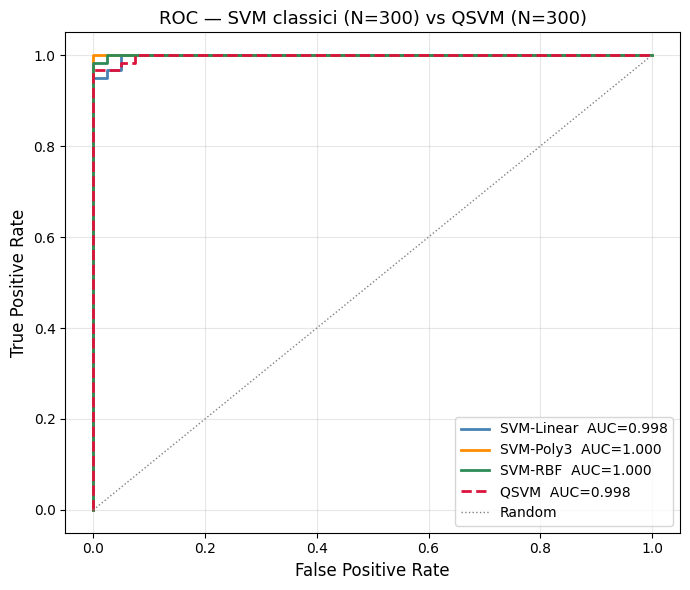

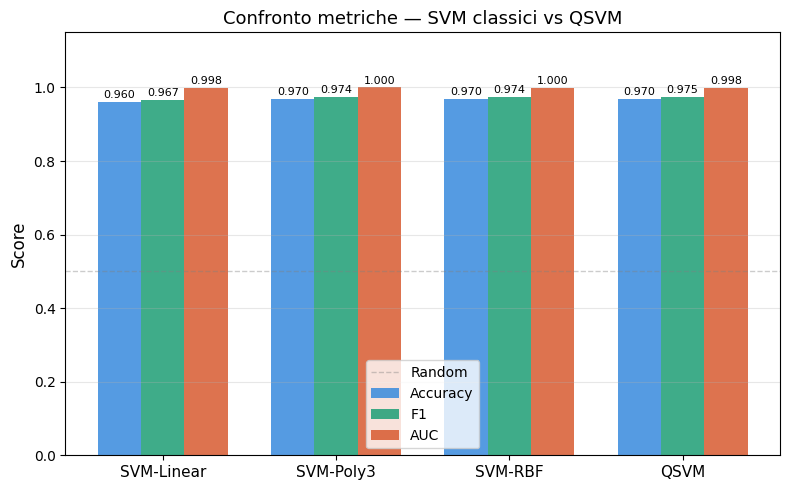

  Modello         Train  Test     AUC     Acc      F1
  SVM-Linear        300   100  0.9979  0.9600  0.9667
  SVM-Poly3         300   100  1.0000  0.9700  0.9744
  SVM-RBF           300   100  0.9996  0.9700  0.9744
  QSVM              300   100  0.9979  0.9700  0.9748


In [21]:
from sklearn.metrics import f1_score, accuracy_score
%matplotlib inline
import matplotlib.pyplot as plt

os.makedirs("risultati", exist_ok=True)

# SCEGLI QUI I VALORI DEL SET DA ANALIZZARE PER IL CLASSIFICATORE CLASSICO


n_train_svm = 300
n_test_svm  = 100

X_tr_svm = X_train_small[:n_train_svm]
Y_tr_svm = Y_train[:n_train_svm]
X_te_svm = X_test_small[:n_test_svm]
Y_te_svm = Y_test[:n_test_svm]


# SVM CLASSICI


classifiers = {
    "SVM-Linear": SVC(kernel="linear", probability=True, C=1.0),
    "SVM-Poly3":  SVC(kernel="poly",   probability=True, degree=3, C=1.0),
    "SVM-RBF":    SVC(kernel="rbf",    probability=True, C=1.0, gamma="scale"),
}

results = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_tr_svm, Y_tr_svm)
    y_pred_cl = clf.predict(X_te_svm)
    sc        = clf.decision_function(X_te_svm)
    fpr_cl, tpr_cl, _ = roc_curve(Y_te_svm, sc, pos_label=1)
    results[name] = {
        "auc": roc_auc_score(Y_te_svm, sc),
        "acc": accuracy_score(Y_te_svm, y_pred_cl),
        "f1":  f1_score(Y_te_svm, y_pred_cl, pos_label=1),
        "fpr": fpr_cl,
        "tpr": tpr_cl,
    }
    print(f"  AUC={results[name]['auc']:.4f}  Acc={results[name]['acc']:.4f}  F1={results[name]['f1']:.4f}")

# aggiungi QSVM — usa scores già calcolato sopra
scores_qsvm = model_svm.decision_function(K_test)
y_pred_q    = model_svm.predict(K_test)
fpr_q, tpr_q, _ = roc_curve(Y_test_q, scores_qsvm, pos_label=1)
results["QSVM"] = {
    "auc": roc_auc_score(Y_test_q, scores_qsvm),
    "acc": accuracy_score(Y_test_q, y_pred_q),
    "f1":  f1_score(Y_test_q, y_pred_q, pos_label=1),
    "fpr": fpr_q,
    "tpr": tpr_q,
}


# GRAFICO 1 — ROC


colors = {
    "SVM-Linear": "steelblue",
    "SVM-Poly3":  "darkorange",
    "SVM-RBF":    "seagreen",
    "QSVM":       "crimson",
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, res in results.items():
    ax.plot(res["fpr"], res["tpr"],
            color=colors[name], lw=2,
            linestyle="--" if name == "QSVM" else "-",
            label=f"{name}  AUC={res['auc']:.3f}")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":", label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC — SVM classici (N={n_train_svm}) vs QSVM (N=300)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# GRAFICO 2 — Accuracy / F1 / AUC a barre


names  = list(results.keys())
accs   = [results[n]["acc"] for n in names]
f1s    = [results[n]["f1"]  for n in names]
aucs   = [results[n]["auc"] for n in names]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, accs, width, label="Accuracy", color="#378ADD", alpha=0.85)
bars2 = ax.bar(x,         f1s,  width, label="F1",       color="#1D9E75", alpha=0.85)
bars3 = ax.bar(x + width, aucs, width, label="AUC",      color="#D85A30", alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", lw=1, linestyle="--", alpha=0.4, label="Random")
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Confronto metriche — SVM classici vs QSVM", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# RIEPILOGO



print(f"  {'Modello':<14} {'Train':>6} {'Test':>5} {'AUC':>7} {'Acc':>7} {'F1':>7}")
print("="*58)
for name, res in results.items():
    n_tr = 300 if name == "QSVM" else n_train_svm
    n_te = 100 if name == "QSVM" else n_test_svm
    print(f"  {name:<14} {n_tr:>6} {n_te:>5} {res['auc']:>7.4f} {res['acc']:>7.4f} {res['f1']:>7.4f}")


Si studia la concentrazione espnenziale: si studia la varianza del kernel al variare del numero di  qubits [2, 4, 6, 8 ,10 ,12,14].


n_qubits = 2 ...
  mean=0.957942  var=0.005191

n_qubits = 4 ...
  mean=0.962706  var=0.001911

n_qubits = 6 ...
  mean=0.968036  var=0.001348

n_qubits = 8 ...
  mean=0.939386  var=0.006146

n_qubits = 10 ...
  mean=0.953819  var=0.001978

n_qubits = 12 ...
  mean=0.947347  var=0.002985

n_qubits = 14 ...
  mean=0.957214  var=0.001902


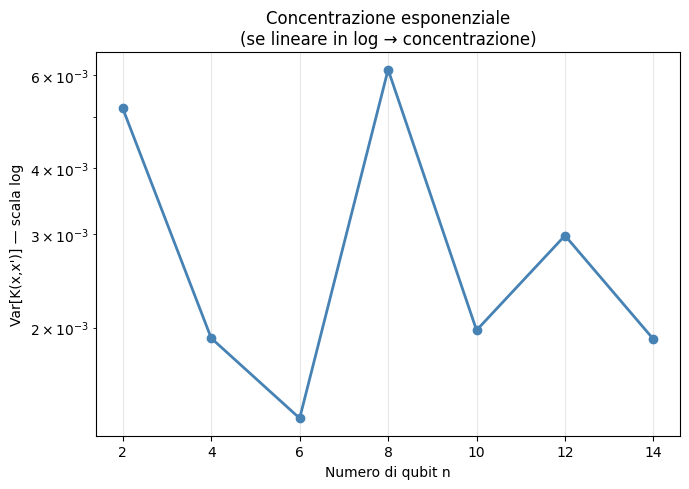

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch

qubit_list = [2, 4, 6, 8 ,10 ,12,14]
n_samples  = 500

def make_feature_map(n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)
    def feature_map(x):
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        for _ in range(2):
            for i in range(n_qubits):
                qml.RY(x[i], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i+1])
    @qml.qnode(dev)
    def kernel_circuit(x1, x2):
        feature_map(x1)
        qml.adjoint(feature_map)(x2)
        return qml.probs(wires=range(n_qubits))
    return lambda x1, x2: float(kernel_circuit(x1, x2)[0])

variances = []
means     = []

for n in qubit_list:
    print(f"\nn_qubits = {n} ...")

    # addestra un encoder con latent_dim = n
    layers  = [400, 256, 128, 64, 32, n]
    model_n = AE_sinkclass(device=device, hpars={"ae_layers": layers})
    model_n.train_autoencoder(train_loader, valid_loader, epochs=200)

    # estrai lo spazio latente
    with torch.no_grad():
        latent_n = model_n.encoder(
            torch.tensor(X_tr[:200], dtype=torch.float32).to(device)
        ).cpu().numpy()                          # shape (200, n)

    X_n = 1 / (1 + np.exp(-latent_n)) * np.pi  # sigmoid × π

    kernel_fn     = make_feature_map(n)
    kernel_values = []

    idx = np.random.choice(len(X_n), size=(n_samples, 2), replace=True)
    for i, j in idx:
        if i != j:
            kernel_values.append(kernel_fn(X_n[i], X_n[j]))

    var  = np.var(kernel_values)
    mean = np.mean(kernel_values)
    variances.append(var)
    means.append(mean)
    print(f"  mean={mean:.6f}  var={var:.6f}")
# PLOT
plt.figure(figsize=(7, 5))
plt.semilogy(qubit_list, variances, "o-", color="steelblue", lw=2)
plt.xlabel("Numero di qubit n")
plt.ylabel("Var[K(x,x')] — scala log")
plt.title("Concentrazione esponenziale\n(se lineare in log → concentrazione)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

